In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
import os
print("All required libraries are imported successfully.")

All required libraries are imported successfully.


In [2]:
# understanding the problem statement

# Data Collection: The data is collected from the US visa application process. It contains information about applicants, their demographics, and the outcome of their visa applications.

# Data Cleaning: The data is cleaned to remove any missing or irrelevant information. This may involve handling missing values, removing duplicates, and standardizing data formats.

#Data Preprocessing: The data is preprocessed to prepare it for analysis. This may involve encoding categorical variables, scaling numerical features, and creating new features based on existing ones.

# Data Analysis: The data is analyzed to identify patterns and trends in the visa application process. This may involve visualizing the data using charts and graphs, calculating summary statistics, and performing hypothesis testing.

# Model Building: Machine learning models are built to predict the outcome of visa applications based on the applicant's demographics and other relevant features. This may involve selecting appropriate algorithms, tuning hyperparameters, and evaluating model performance using metrics such as accuracy, precision, and recall.

# Model Deployment: The trained models are deployed to a production environment where they can be used to make predictions on new visa applications. This may involve integrating the models into an existing application or creating a new application that uses the models to provide recommendations to applicants.


In [4]:
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("EasyVisa.csv")

In [6]:
df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [7]:
# Show the first few rows of the dataset
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [9]:
# Show the last few rows of the dataset
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [10]:
# Shape of the dataset
df.shape

(25480, 12)

In [13]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [14]:
# Uncessary columns in the dataset
# unnecessary_columns = ['Unnamed: 0', 'Case Number', 'Case Status', ']

In [15]:
# Display summary statistics for numerical columns
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [16]:
# EXPLORATORY DATA ANALYSIS (EDA)

In [17]:
# define numerical and categorical columns

numerical_columns = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_columns = [feature for feature in df.columns if df[feature].dtype == 'O']

# numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# categorical_columns = df.select_dtypes(include=[object]).columns.tolist()

In [18]:
numerical_columns

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [19]:
categorical_columns

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [21]:
len(numerical_columns), len(categorical_columns)

(3, 9)

In [23]:
# Porportion of numerical and categorical columns

for col in categorical_columns:
    print(df[col].value_counts(normalize=True) * 100)
    print("=============================================================")

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
unit_o

In [24]:
for col in numerical_columns:

    print(df[col].value_counts(normalize=True) * 100)
    print("=============================================================")

no_of_employees
183      0.070644
854      0.062794
724      0.062794
766      0.058870
1476     0.058870
           ...   
5876     0.003925
5536     0.003925
47866    0.003925
4700     0.003925
40224    0.003925
Name: proportion, Length: 7105, dtype: float64
yr_of_estab
1998    4.450549
2005    4.124804
2001    3.991366
2007    3.901099
1999    3.414443
          ...   
1842    0.023548
1846    0.015699
1822    0.015699
1810    0.011774
1824    0.007849
Name: proportion, Length: 199, dtype: float64
prevailing_wage
82560.2800     0.007849
122.6500       0.007849
60948.1500     0.007849
64357.5800     0.007849
108.1200       0.007849
                 ...   
25713.9800     0.003925
101656.6400    0.003925
65665.5500     0.003925
50.8813        0.003925
70876.9100     0.003925
Name: proportion, Length: 25454, dtype: float64


In [25]:
# Insight
# 01. The dataset contains a total of 10 columns, out of which 6 are categorical and 4 are numerical. This indicates that the dataset has a mix of both types of data, which may require different preprocessing techniques for analysis.

# 02. The categorical columns have varying proportions of values, with some columns having a dominant category while others have a more even distribution. This suggests that some features may be more informative than others for predicting the outcome of visa applications.

#03. The numerical columns also have varying proportions of values, with some columns having a skewed distribution while others have a more normal distribution. This may require different scaling techniques for analysis.

In [27]:
# UNIVARIATE ANALYSIS
      # The univariate analysis is the simplest form of analyzing data. "Uni" means "one", so in other words your data has only one variable. The purpose of the univariate analysis is to describe; it takes data, summarizes that data and finds patterns in the data. The univariate analysis does not deal with causes or relationships (unlike regression) and its major purpose is to describe the data and find patterns that exist within it.

# BIVARIATE ANALYSIS
      # Bivariate analysis is the analysis of two variables. The purpose of bivariate analysis is to find out the empirical relationship between two variables. The bivariate analysis is used to find out the relationship between two variables. It is used to find out the correlation between two variables. The bivariate analysis is used to find out the relationship between two variables. It is used to find out the correlation between two variables. The bivariate analysis is used to find out the relationship between two variables. It is used to find out the correlation between two variables. The bivariate analysis is used to find out the relationship between two variables. It is used to find out the correlation between two variables. The bivariate analysis is used to find out the relationship between two variables.


In [28]:
# NUMBERICAL COLUMNS

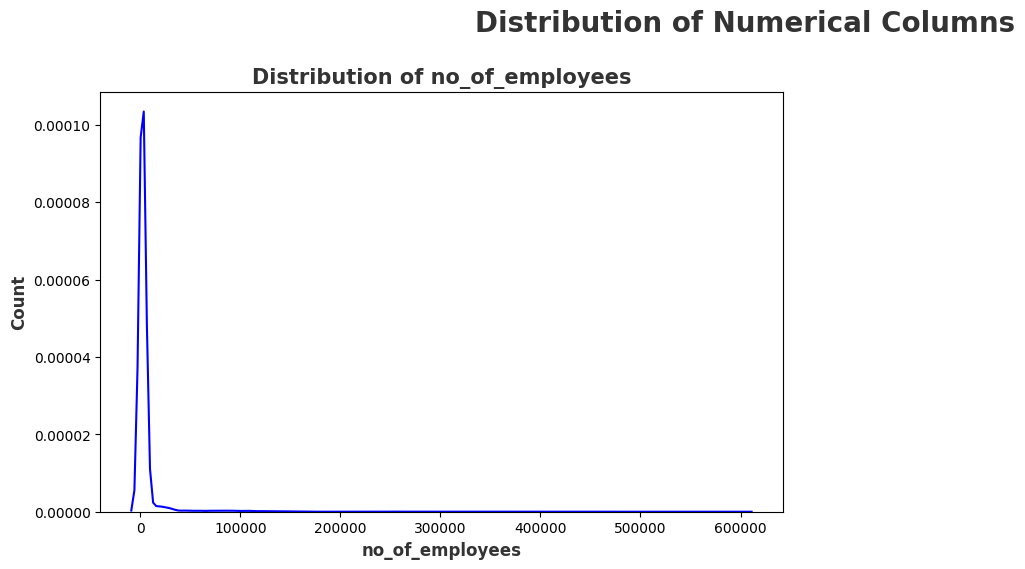

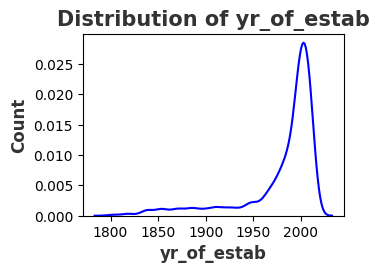

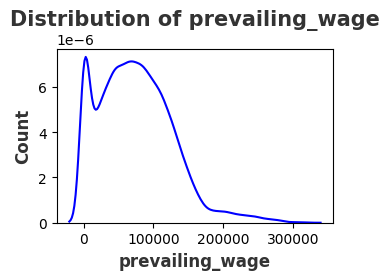

In [34]:
plt.figure(figsize=(15, 10))
plt.suptitle("Distribution of Numerical Columns", fontsize=20, fontweight='bold', alpha=0.8, y=1.)
path="C:\\Users\\MeanderSoftware\\Desktop\\MACHINE LEARNING PROJECT\\Project 01\\notebook\\Images"

for i in range(len(numerical_columns)):
    plt.subplot(2, 2, i + 1)
    sns.kdeplot(x=df[numerical_columns[i]],color='blue')
    plt.title(f'Distribution of {numerical_columns[i]}', fontsize=15, fontweight='bold', alpha=0.8)
    plt.xlabel(numerical_columns[i], fontsize=12, fontweight='bold', alpha=0.8)
    plt.ylabel('Count', fontsize=12, fontweight='bold', alpha=0.8)
    plt.tight_layout()
    plt.savefig(f'{path}/Distribution of {numerical_columns[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [35]:
# Insight

# 01. no_of_employees column has a right-skewed distribution, indicating that most companies have a small number of employees, while a few companies have a large number of employees. This may suggest that the size of the company could be an important factor in predicting the outcome of visa applications.

# 02. yr_of_estab is distributed normally, indicating that the majority of companies were established in the middle range of years, while fewer companies were established in the early or late years. This may suggest that the age of the company could also be an important factor in predicting the outcome of visa applications.

# 03. Privailing_wage column has a right-skewed distribution, indicating that most companies pay a lower wage, while a few companies pay a higher wage. This may suggest that the wage offered by the company could be an important factor in predicting the outcome of visa applications.



In [36]:
# CATEGORICAL COLUMNS

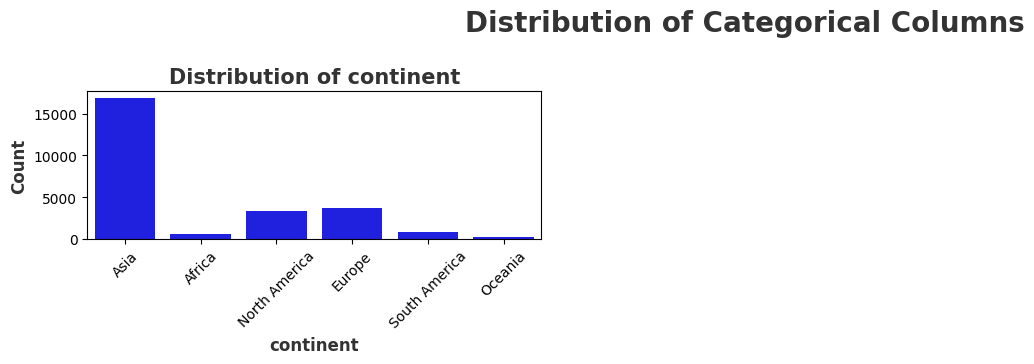

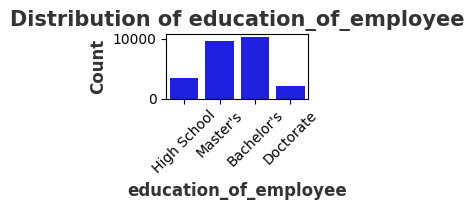

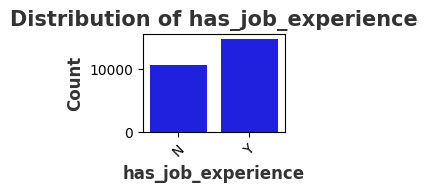

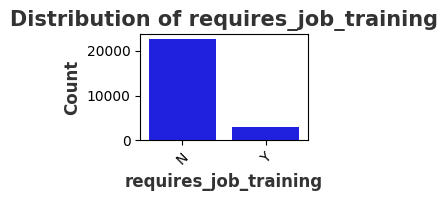

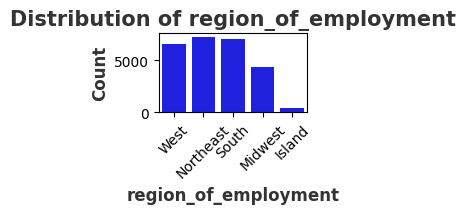

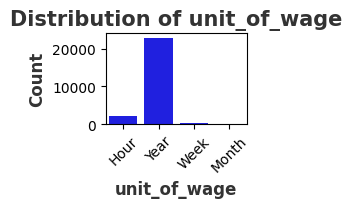

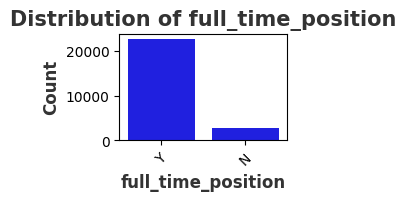

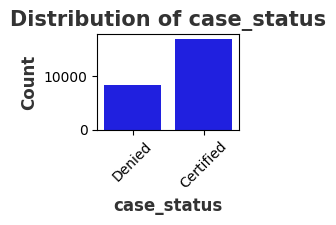

In [40]:

plt.figure(figsize=(15, 8))
plt.suptitle("Distribution of Categorical Columns", fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(len(categorical_columns)):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=df[categorical_columns[i]], color='blue')
    plt.title(f'Distribution of {categorical_columns[i]}', fontsize=15, fontweight='bold', alpha=0.8)
    plt.xlabel(categorical_columns[i], fontsize=12, fontweight='bold', alpha=0.8)
    plt.ylabel('Count', fontsize=12, fontweight='bold', alpha=0.8)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{path}/Distribution of {categorical_columns[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [41]:
# Insight

# 01. The distribution of numerical columns shows that some features have a skewed distribution, while others have a more normal distribution. This may require different scaling techniques for analysis.

# 02. The distribution of categorical columns shows that some features have a dominant category, while others have a more even distribution. This may suggest that some features may be more informative than others for predicting the outcome of visa applications.

# 03. The distribution of the target variable shows that the majority of visa applications are approved, while a smaller number are denied. This may indicate a potential imbalance in the dataset that should be addressed during modeling.

# 04. The distribution of the target variable shows that the majority of visa applications are approved, while a smaller number are denied. This may indicate a potential imbalance in the dataset that should be addressed during modeling.

In [42]:
# MULTIVARIATE ANALYSIS

In [44]:
discrete_features = [feature for feature in numerical_columns if len(df[feature].unique()) < 25]
continuous_features = [feature for feature in numerical_columns if len(df[feature].unique()) >= 25]

print('We have {} discrete features and {} continuous features.'.format(len(discrete_features), len(continuous_features)))
print('\n We have {} discrete features and {} continuous features.'.format(len(discrete_features), len(continuous_features))) 

We have 0 discrete features and 3 continuous features.

 We have 0 discrete features and 3 continuous features.


In [45]:
# CHECK THE MULTICOLLINEARITY BETWEEN THE NUMERICAL COLUMNS

In [46]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
